# Connessione al db

In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

import matplotlib.pyplot as plt
import os

# Configurazione pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# pip install nbconvert
import subprocess
import sys

# Esegui setup_raw_data.py
result_setup = subprocess.run([sys.executable, '../script/setup_raw_data.py'], 
                              capture_output=True, text=True)
print(result_setup.stdout)
if result_setup.stderr:
    print("STDERR:", result_setup.stderr)

# Esegui notebook pulizia con nbconvert
result_clean = subprocess.run([
    sys.executable, '-m', 'nbconvert', 
    '--to', 'notebook', 
    '--execute', 
    '--ExecutePreprocessor.timeout=600',
    '../notebook/pulizia.ipynb'
], capture_output=True, text=True, cwd='.')

print(result_clean.stdout)
if result_clean.stderr:
    print("STDERR:", result_clean.stderr)


Creazione tabella raw_data...
Tabella raw_data creata

Credenziali caricate!
Credenziali caricate da: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\script\..\local\analisi-ansia-dcecdb75c868.json

Connessione a Google Sheets...
Trovate 169 risposte
Numero colonne: 39

Inizio importazione dati in raw_data...

Salvate 10 righe...
Salvate 20 righe...
Salvate 30 righe...
Salvate 40 righe...
Salvate 50 righe...
Salvate 60 righe...
Salvate 70 righe...
Salvate 80 righe...
Salvate 90 righe...
Salvate 100 righe...
Salvate 110 righe...
Salvate 120 righe...
Salvate 130 righe...
Salvate 140 righe...
Salvate 150 righe...
Salvate 160 righe...

Importazione completata!
   - Righe inserite: 169
   - Righe saltate: 0

Fine

STDERR: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in ne

In [3]:
conn = get_mysql_connection()

# Carica tutti i dati da raw_data in un DataFrame
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)

conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()

Dataset caricato: 147 righe, 37 colonne


C:\Users\Utente\AppData\Local\Temp\ipykernel_15904\3523368477.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,4,4,4.0,4.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
1,2,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,4,3,4.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,4,1,3,3,5,2,2,2,4,Durante gli esami
2,3,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,4,4,4.0,5.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,2.0,4.0,5.0,5.0,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti)
3,4,None,Entrambi,26,Femmina,Nord Italia,5.0,2,4,3,5,5,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,5.0,3.0,5.0,3.0,2,5,3,3,2,3,2,1,3,L’esame
4,5,None,Studio,22,Femmina,Nord Italia,2.0,3,2,3,4,4,3.0,2.0,2.0,3.0,1.0,4.0,3.0,3.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,2,2,3,2,4,3,3,2,4,"Durante il tirocinio, quando devo mettere effe..."


# Calcolo degli indici

In [4]:
df["ansia_prestazione"] = df[["Item_1", "Item_2", "Item_3", "Item_4", "Item_6", "Item_11", "Item_20", "Item_21"]].mean(axis=1)
df["ansia_accademica"] = df[["Item_7", "Item_8", "Item_9", "Item_10"]].mean(axis=1)
df["ansia_lavorativa"] = df[["Item_12", "Item_13", "Item_14", "Item_15"]].mean(axis=1)
df["perfezionismo"] = df[["Item_16", "Item_17", "Item_18", "Item_19"]].mean(axis=1)
df["impatto_ansia"] = df[["Item_5", "Item_22", "Item_27", "Item_28", "Item_29"]].mean(axis=1)
df["coping"] = df[["Item_23", "Item_24", "Item_25", "Item_26"]].mean(axis=1)

In [5]:
# ansia totale
df['ansia'] = df[["ansia_prestazione", "ansia_accademica", "ansia_lavorativa"]].mean(axis=1)

In [6]:
# fragilità/esposizione allo stress
df["vulnerabilita"] = (df["perfezionismo"] + df["ansia"]) / 2

# capacità di fronteggiare l'ansia
df["resilienza"] = (df["coping"] - df["ansia"])

# gap percezione-prestazione (quanto l’ansia distorce la performance )
df["gap"] = (df["Item_8"] - df["coping"])

# evitamento delle situazioni che mettono ansia
df["evitamento"] = df[["Item_10", "Item_15", "Item_27", "Item_28"]].mean(axis=1)

# intensità dei sintomi
df["intensita_sintomatica"] = df [["Item_20", "Item_21", "Item_22"]].mean(axis=1)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     147 non-null    int64  
 1   email                  12 non-null     object 
 2   contesto               147 non-null    object 
 3   età                    147 non-null    int64  
 4   genere                 147 non-null    object 
 5   area_geo               147 non-null    object 
 6   anni_esperienza        147 non-null    float64
 7   Item_1                 147 non-null    int64  
 8   Item_2                 147 non-null    int64  
 9   Item_3                 147 non-null    int64  
 10  Item_4                 147 non-null    int64  
 11  Item_5                 147 non-null    int64  
 12  Item_6                 144 non-null    float64
 13  Item_7                 144 non-null    float64
 14  Item_8                 144 non-null    float64
 15  Item_9

# Distribuzioni

(array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5]),
 [Text(0.5, 0, '0.5'),
  Text(1.0, 0, '1.0'),
  Text(1.5, 0, '1.5'),
  Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5'),
  Text(4.0, 0, '4.0'),
  Text(4.5, 0, '4.5'),
  Text(5.0, 0, '5.0'),
  Text(5.5, 0, '5.5')])

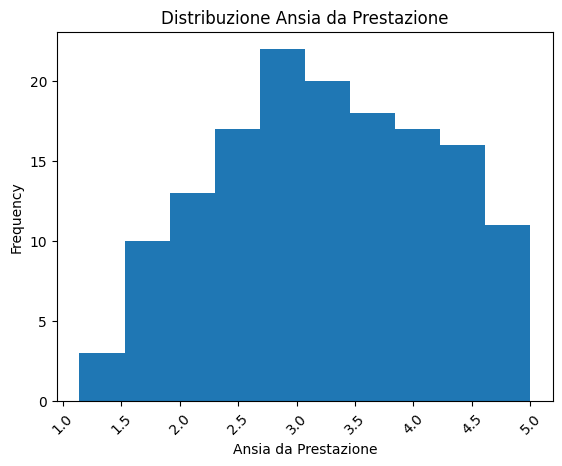

In [8]:
import matplotlib.pyplot as plt

df["ansia_prestazione"].plot(kind = 'hist')
plt.xlabel('Ansia da Prestazione')
plt.title('Distribuzione Ansia da Prestazione')
plt.xticks(rotation=45)

# Correlazioni

## Correlazioni Claude

In [9]:
# Variabili da analizzare
vars_to_analyze = [
    'ansia', 'coping', 'perfezionismo', 'vulnerabilita', 
    'resilienza', 'gap', 'evitamento', 'intensita_sintomatica',
    'impatto_ansia', 'ansia_prestazione', 'ansia_accademica', 
    'ansia_lavorativa'
]

# Filtra solo le colonne che esistono
vars_available = [v for v in vars_to_analyze if v in df.columns]
print(f"Variabili disponibili: {len(vars_available)}/{len(vars_to_analyze)}")
print(vars_available)

Variabili disponibili: 12/12
['ansia', 'coping', 'perfezionismo', 'vulnerabilita', 'resilienza', 'gap', 'evitamento', 'intensita_sintomatica', 'impatto_ansia', 'ansia_prestazione', 'ansia_accademica', 'ansia_lavorativa']


In [10]:
# Matrice di correlazione
corr_matrix = df[vars_available].corr(method='pearson')

print(f"\nMatrice di correlazione {corr_matrix.shape}:")
print(corr_matrix.round(3))


Matrice di correlazione (12, 12):
                       ansia  coping  perfezionismo  vulnerabilita  \
ansia                  1.000  -0.491          0.627          0.882   
coping                -0.491   1.000         -0.312         -0.434   
perfezionismo          0.627  -0.312          1.000          0.920   
vulnerabilita          0.882  -0.434          0.920          1.000   
resilienza            -0.878   0.848         -0.551         -0.772   
gap                    0.737  -0.671          0.459          0.666   
evitamento             0.792  -0.498          0.481          0.683   
intensita_sintomatica  0.805  -0.406          0.629          0.771   
impatto_ansia          0.805  -0.418          0.628          0.783   
ansia_prestazione      0.922  -0.484          0.663          0.861   
ansia_accademica       0.894  -0.464          0.498          0.763   
ansia_lavorativa       0.862  -0.318          0.350          0.655   

                       resilienza    gap  evitamento  

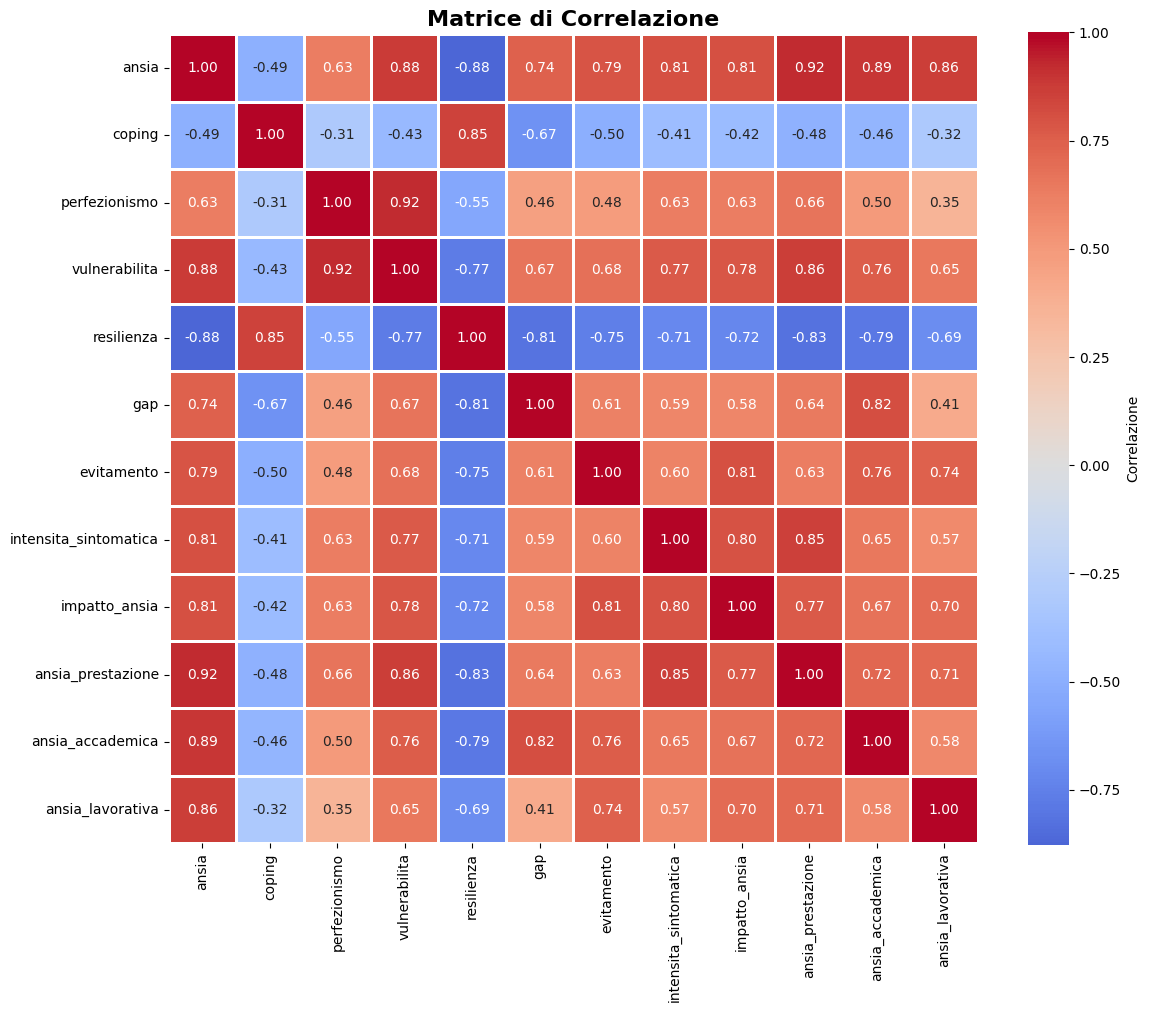

In [11]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={'label': 'Correlazione'})
plt.title('Matrice di Correlazione', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
import scipy.stats as stats
from scipy.stats import pearsonr

# Rimuovi righe con NaN per tutte le variabili insieme
df_clean = df[vars_available].dropna()

# Estrai tutte le coppie di correlazioni
correlations_list = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]

        # Calcola p-value usando i dati puliti
        r, p_value = pearsonr(df_clean[var1], df_clean[var2])

        correlations_list.append({
            'Variabile 1': var1,
            'Variabile 2': var2,
            'Correlazione': corr_value,
            'Abs_Corr': abs(corr_value),
            'P-value': p_value,
            'Significativa': 'Sì' if p_value < 0.05 else 'No'
        })

corr_df = pd.DataFrame(correlations_list)
corr_df_sorted = corr_df.sort_values('Abs_Corr', ascending=False)

print(f"\nTOP 15 CORRELAZIONI (su {len(corr_df)} totali) - Dataset pulito: {df_clean.shape[0]} righe")
print(corr_df_sorted.head(15).to_string(index=False))


TOP 15 CORRELAZIONI (su 66 totali) - Dataset pulito: 38 righe
          Variabile 1           Variabile 2  Correlazione  Abs_Corr      P-value Significativa
                ansia     ansia_prestazione      0.922039  0.922039 2.082988e-13            Sì
        perfezionismo         vulnerabilita      0.920049  0.920049 2.414804e-13            Sì
                ansia      ansia_accademica      0.893686  0.893686 4.033946e-13            Sì
                ansia         vulnerabilita      0.882174  0.882174 2.639129e-11            Sì
                ansia            resilienza     -0.877821  0.877821 2.853527e-12            Sì
                ansia      ansia_lavorativa      0.862286  0.862286 5.966684e-10            Sì
        vulnerabilita     ansia_prestazione      0.861436  0.861436 1.133883e-10            Sì
intensita_sintomatica     ansia_prestazione      0.853828  0.853828 4.060124e-08            Sì
               coping            resilienza      0.848478  0.848478 7.177595e-14  

In [13]:
# Definisci coppie target da regressare
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

regression_targets = [
    ('ansia', 'coping'),
    ('ansia', 'gap'),
    ('ansia', 'evitamento'),
    ('perfezionismo', 'coping'),
]

# Definisci features
feature_sets = {
    'Univariata': lambda x, y: [x],
    'Multivariata (3 var)': lambda x, y: [x, 'perfezionismo', 'vulnerabilita'],
    'Multivariata (5 var)': lambda x, y: [x, 'perfezionismo', 'vulnerabilita', 'impatto_ansia', 'intensita_sintomatica'],
    'Multivariata (tutte)': lambda x, y: [v for v in vars_available if v != y]
}

results = []

for target_x, target_y in regression_targets:
    print(f"Regressione: {target_x} -> {target_y}")
    
    # Prepara dati
    df_clean = df[[target_x, target_y] + vars_available].dropna()
    
    if len(df_clean) < 10:
        print(f"Dataset troppo piccolo ({len(df_clean)} campioni), salta")
        continue
    
    for feature_name, feature_func in feature_sets.items():
        features = feature_func(target_x, target_y)
        
        # Controlla se features esistono
        features = [f for f in features if f in df_clean.columns]
        if not features:
            continue
        
        X = df_clean[features].values
        y = df_clean[target_y].values
        
        # Normalizza
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )
        
        # Linear Regression
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        
        results.append({
            'Predittore': target_x,
            'Target': target_y,
            'Modello': 'Linear',
            'Features': feature_name,
            'N_Features': len(features),
            'R²': r2,
            'RMSE': rmse,
            'MAE': mae
        })
        
        print(f"\n  {feature_name}:")
        print(f"    Features: {len(features)} - {features[:3]}{'...' if len(features) > 3 else ''}")
        print(f"    R²: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

Regressione: ansia -> coping

  Univariata:
    Features: 1 - ['ansia']
    R²: -0.0193, RMSE: 1.0929, MAE: 0.9738

  Multivariata (3 var):
    Features: 3 - ['ansia', 'perfezionismo', 'vulnerabilita']
    R²: 0.0269, RMSE: 1.0679, MAE: 0.9469

  Multivariata (5 var):
    Features: 5 - ['ansia', 'perfezionismo', 'vulnerabilita']...
    R²: -0.0019, RMSE: 1.0835, MAE: 0.9511

  Multivariata (tutte):
    Features: 11 - ['ansia', 'perfezionismo', 'vulnerabilita']...
    R²: 1.0000, RMSE: 0.0000, MAE: 0.0000
Regressione: ansia -> gap

  Univariata:
    Features: 1 - ['ansia']
    R²: 0.3925, RMSE: 1.2740, MAE: 1.1768

  Multivariata (3 var):
    Features: 3 - ['ansia', 'perfezionismo', 'vulnerabilita']
    R²: 0.3928, RMSE: 1.2737, MAE: 1.1527

  Multivariata (5 var):
    Features: 5 - ['ansia', 'perfezionismo', 'vulnerabilita']...
    R²: 0.3207, RMSE: 1.3473, MAE: 1.1592

  Multivariata (tutte):
    Features: 11 - ['ansia', 'coping', 'perfezionismo']...
    R²: 0.7649, RMSE: 0.7926, MAE:

In [14]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Per la coppia migliore: Ansia -> Coping
target_x = 'ansia'
target_y = 'coping'
features = [v for v in vars_available if v != target_y]

df_clean = df[[target_x, target_y] + features].dropna()
X = df_clean[features].values
y = df_clean[target_y].values  # Rimuovi reshape, mantieni 1D
y = y.flatten()  # Assicurati che sia 1D

# Normalizza
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Modelli
models = {
    'Linear': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=0.1)': Ridge(alpha=0.1),
    'Lasso (alpha=0.01)': Lasso(alpha=0.01),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print(f"\nCOMPARAZIONE MODELLI: {target_x} -> {target_y}")
print(f"{'='*80}")

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Predittore': target_x,
        'Target': target_y,
        'Modello': model_name,
        'Features': f'Multivariata ({len(features)})',
        'N_Features': len(features),
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae
    })
    
    print(f"\n{model_name}:")
    print(f"  R²: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")


COMPARAZIONE MODELLI: ansia -> coping

Linear:
  R²: 1.0000
  RMSE: 0.0000
  MAE: 0.0000

Ridge (alpha=1.0):
  R²: 0.9476
  RMSE: 0.2478
  MAE: 0.2159

Ridge (alpha=0.1):
  R²: 0.9982
  RMSE: 0.0462
  MAE: 0.0408

Lasso (alpha=0.01):
  R²: 0.9896
  RMSE: 0.1102
  MAE: 0.0893

Random Forest:
  R²: 0.5234
  RMSE: 0.7473
  MAE: 0.6372

Gradient Boosting:
  R²: 0.6630
  RMSE: 0.6285
  MAE: 0.4918


## Correlazioni singole

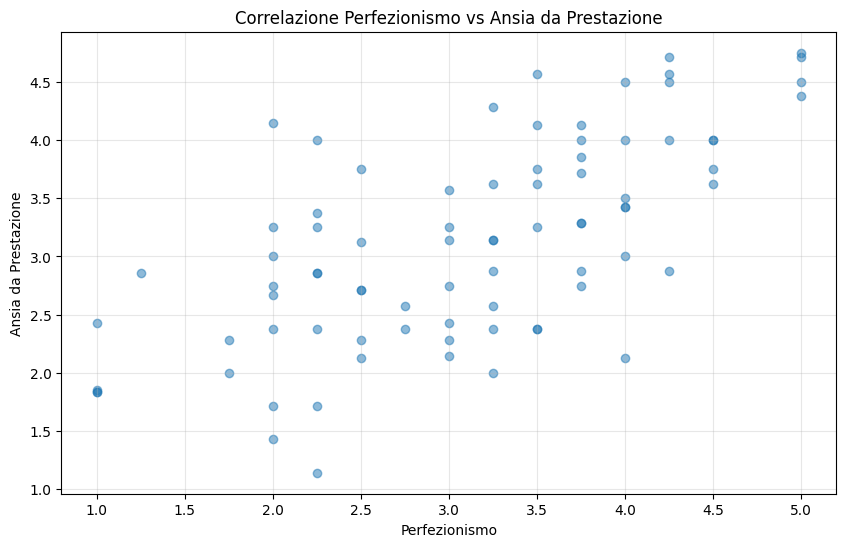

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(df["perfezionismo"], df["ansia_prestazione"], alpha=0.5)
plt.xlabel('Perfezionismo')
plt.ylabel('Ansia da Prestazione')
plt.title(f'Correlazione Perfezionismo vs Ansia da Prestazione')
plt.grid(True, alpha=0.3)

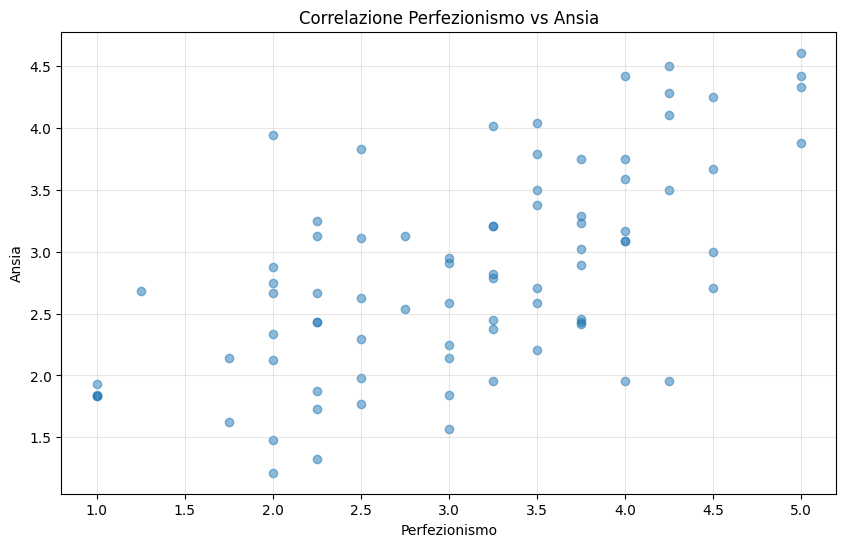

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df["perfezionismo"], df["ansia"], alpha=0.5)
plt.xlabel('Perfezionismo')
plt.ylabel('Ansia')
plt.title(f'Correlazione Perfezionismo vs Ansia')
plt.grid(True, alpha=0.3)

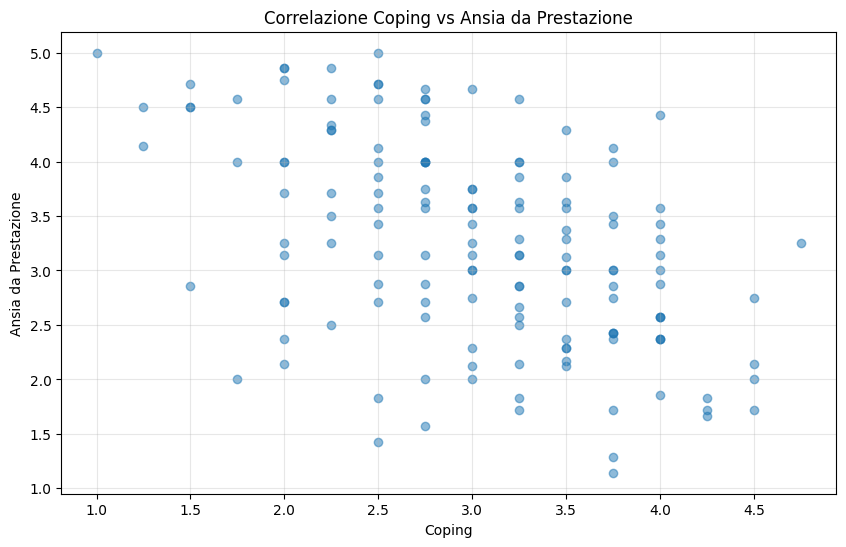

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(df["coping"], df["ansia_prestazione"], alpha=0.5)
plt.xlabel('Coping')
plt.ylabel('Ansia da Prestazione')
plt.title(f'Correlazione Coping vs Ansia da Prestazione')
plt.grid(True, alpha=0.3)

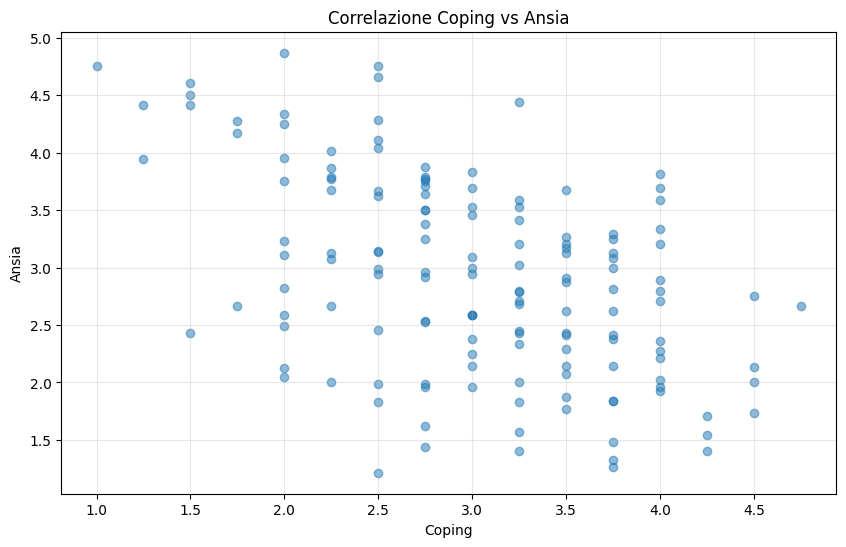

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(df["coping"], df["ansia"], alpha=0.5)
plt.xlabel('Coping')
plt.ylabel('Ansia')
plt.title(f'Correlazione Coping vs Ansia')
plt.grid(True, alpha=0.3)

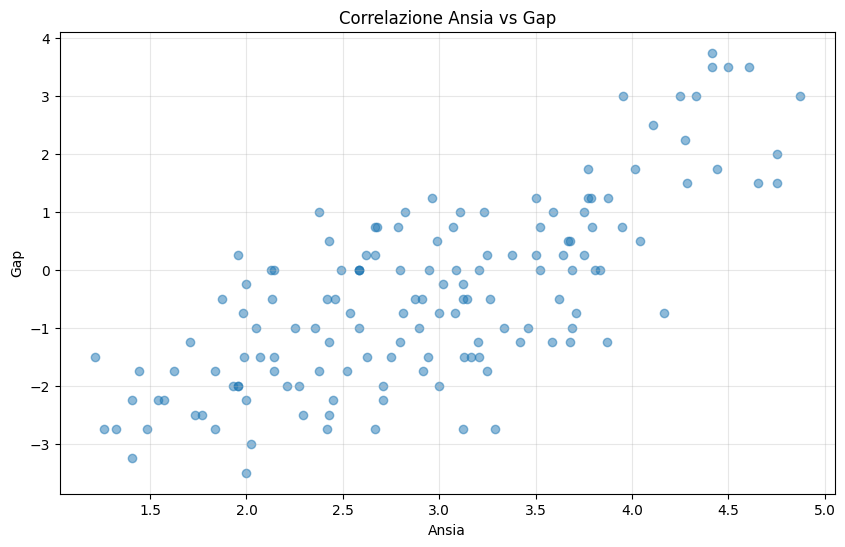

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df["ansia"], df["gap"], alpha=0.5)
plt.xlabel('Ansia')
plt.ylabel('Gap')
plt.title(f'Correlazione Ansia vs Gap')
plt.grid(True, alpha=0.3)

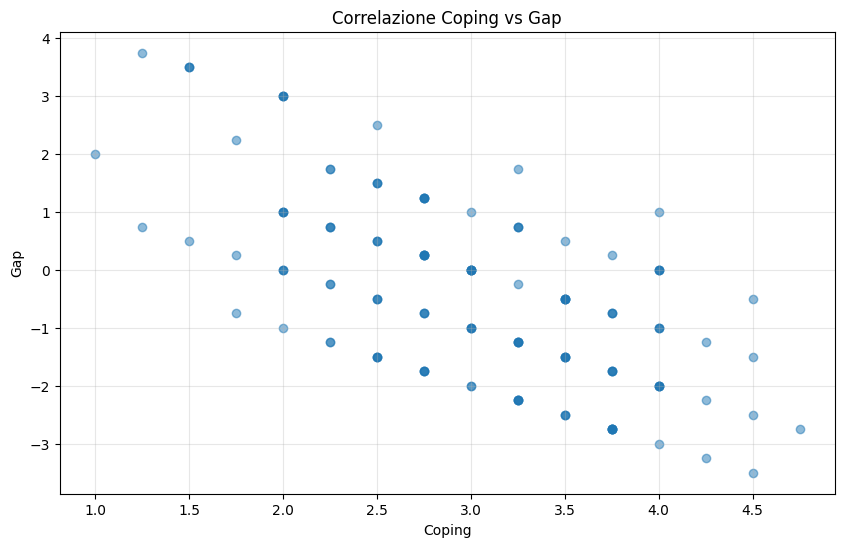

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df["coping"], df["gap"], alpha=0.5)
plt.xlabel('Coping')
plt.ylabel('Gap')
plt.title(f'Correlazione Coping vs Gap')
plt.grid(True, alpha=0.3)

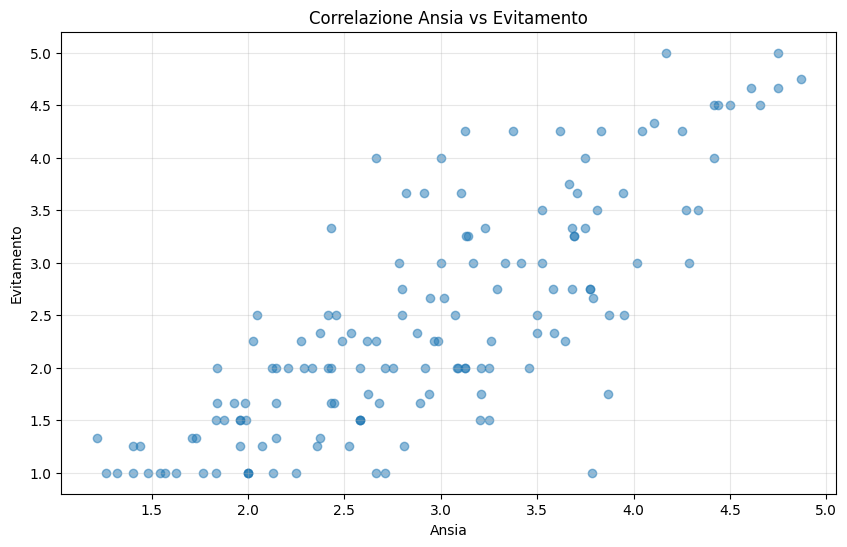

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df["ansia"], df["evitamento"], alpha=0.5)
plt.xlabel('Ansia')
plt.ylabel('Evitamento')
plt.title(f'Correlazione Ansia vs Evitamento')
plt.grid(True, alpha=0.3)

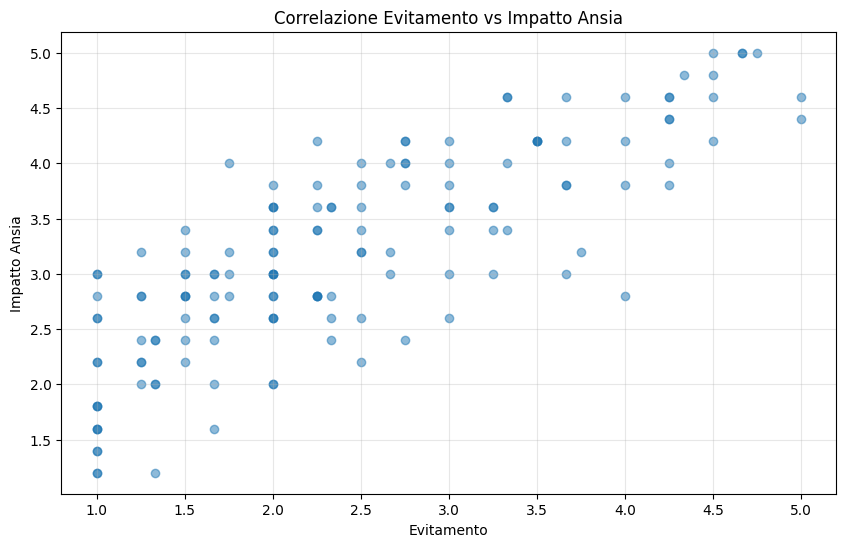

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(df["evitamento"], df["impatto_ansia"], alpha=0.5)
plt.xlabel('Evitamento')
plt.ylabel('Impatto Ansia')
plt.title(f'Correlazione Evitamento vs Impatto Ansia')
plt.grid(True, alpha=0.3)

# Correlazioni avanzate

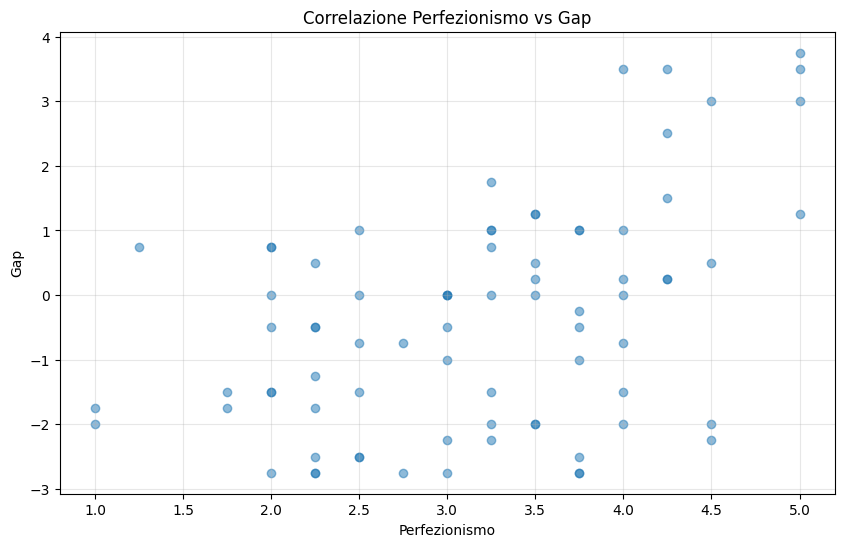

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(df["perfezionismo"], df["gap"], alpha=0.5)
plt.xlabel('Perfezionismo')
plt.ylabel('Gap')
plt.title(f'Correlazione Perfezionismo vs Gap')
plt.grid(True, alpha=0.3)

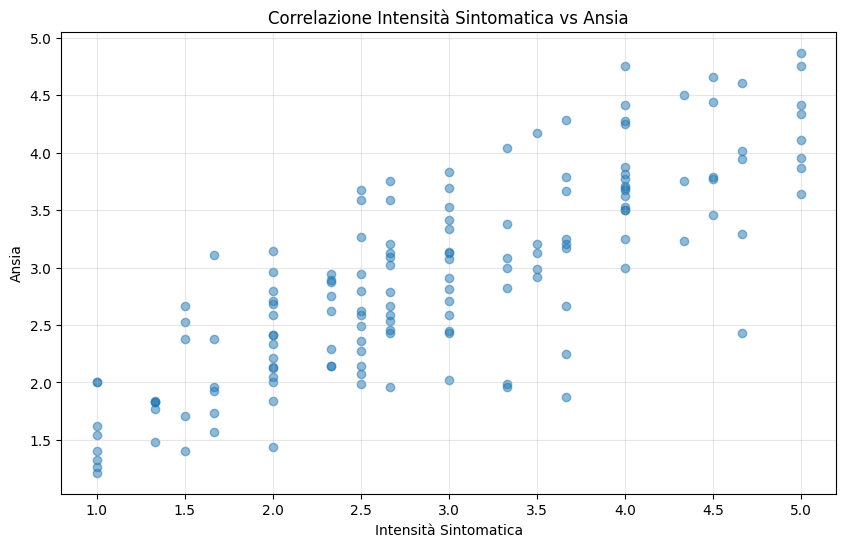

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(df["intensita_sintomatica"], df["ansia"], alpha=0.5)
plt.xlabel('Intensità Sintomatica')
plt.ylabel('Ansia')
plt.title(f'Correlazione Intensità Sintomatica vs Ansia')
plt.grid(True, alpha=0.3)

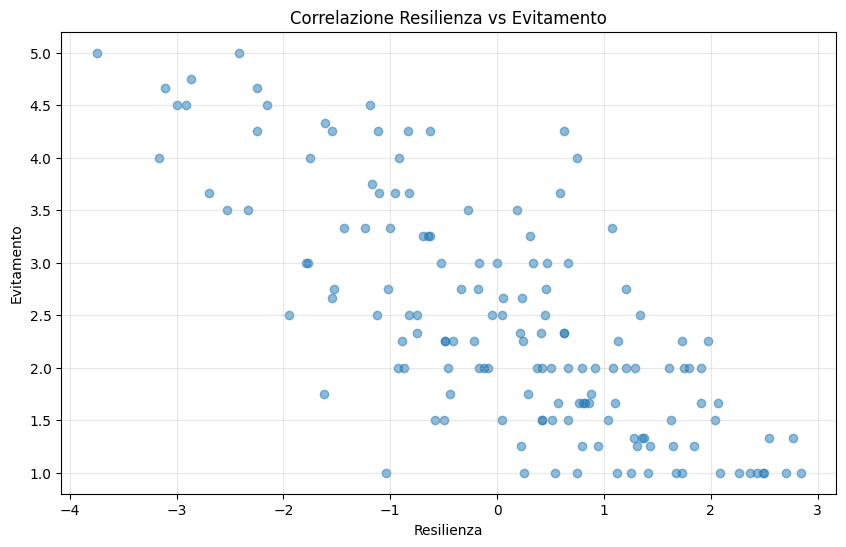

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(df["resilienza"], df["evitamento"], alpha=0.5)
plt.xlabel('Resilienza')
plt.ylabel('Evitamento')
plt.title(f'Correlazione Resilienza vs Evitamento')
plt.grid(True, alpha=0.3)

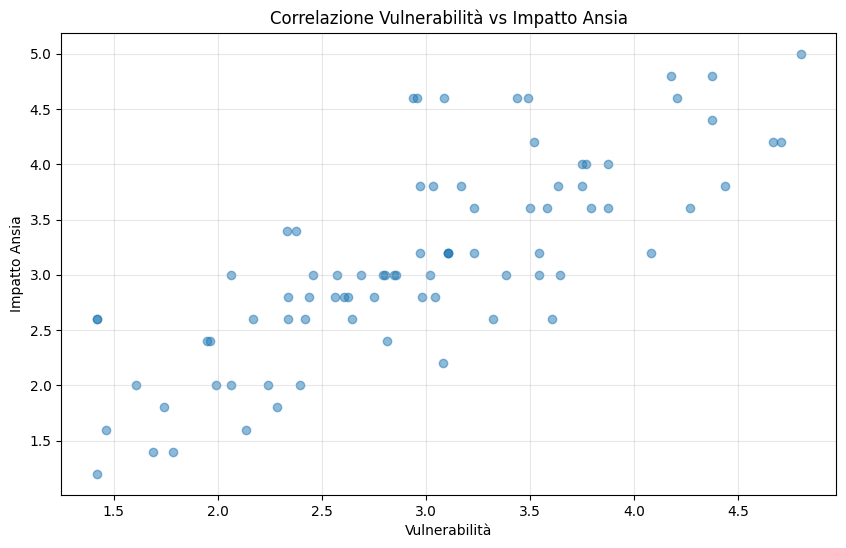

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(df["vulnerabilita"], df["impatto_ansia"], alpha=0.5)
plt.xlabel('Vulnerabilità')
plt.ylabel('Impatto Ansia')
plt.title(f'Correlazione Vulnerabilità vs Impatto Ansia')
plt.grid(True, alpha=0.3)

# Regressioni

In [27]:
#import librerie
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
# Funzione per salvare i grafici
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    # eliminazione file prima di salvare
    if os.path.exists(f"../images/{fig_id}.{fig_extension}"):
        os.remove(f"../images/{fig_id}.{fig_extension}")
    path = os.path.join("../images", fig_id + "." + fig_extension)
    os.makedirs("../images", exist_ok=True)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

### 1) Regressione: Resilienza vs Evitamento

In [29]:
# suddivisione tra X e y
X_1 = df[['resilienza']].values
y_1 = df['evitamento'].values

In [30]:
# suddivisione tra train e test
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

In [31]:
# istanza del modello
lin_reg = LinearRegression()
lin_reg.fit(X_train_1, y_train_1)

# Predizione
y_pred_1 = lin_reg.predict(X_test_1)

In [32]:
#valutazione
mse_1 = mean_squared_error(y_test_1, y_pred_1)
r2_1 = r2_score(y_test_1, y_pred_1)
print("Mean Squared Error:", mse_1)
print("R-squared:", r2_1)

Mean Squared Error: 0.33992547010286056
R-squared: 0.628747211240724


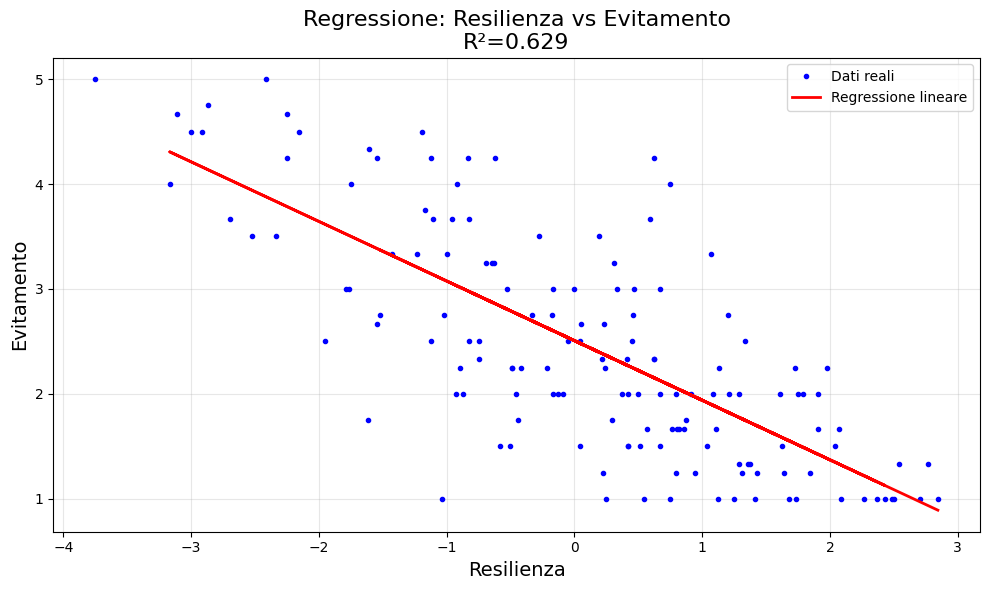

Coefficiente: -0.5680
Intercetta: 2.5074


In [33]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_1, y_1, "b.", label='Dati reali')
plt.plot(X_test_1[:,0], y_pred_1, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Resilienza", fontsize=14)
plt.ylabel("Evitamento", fontsize=14)
plt.title(f'Regressione: Resilienza vs Evitamento\nR²={r2_1:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_resilienza_evitamento")
plt.show()

print(f"Coefficiente: {lin_reg.coef_[0]:.4f}")
print(f"Intercetta: {lin_reg.intercept_:.4f}")

### 2) Regressione: Ansia vs Evitamento

In [34]:
X_2 = df[['ansia']].values
y_2 = df['evitamento'].values

In [35]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

In [36]:
# Modello
lin_reg2 = LinearRegression()
lin_reg2.fit(X_train_2, y_train_2)
y_pred_2 = lin_reg2.predict(X_test_2)

In [37]:
mse_2 = mean_squared_error(y_test_2, y_pred_2)
r2_2 = r2_score(y_test_2, y_pred_2)
print("Mean Squared Error:", mse_2)
print("R-squared:", r2_2)

Mean Squared Error: 0.3328157510427421
R-squared: 0.6365121575613549


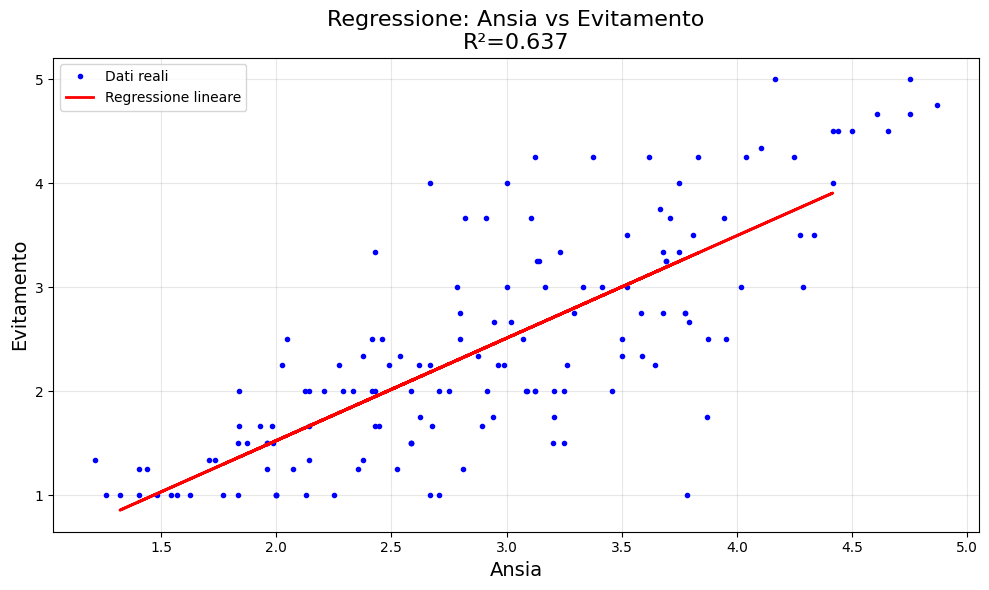

Coefficiente: 0.9853
Intercetta: -0.4474


In [38]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_2, y_2, "b.", label='Dati reali')
plt.plot(X_test_2[:,0], y_pred_2, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=14)
plt.ylabel("Evitamento", fontsize=14)
plt.title(f'Regressione: Ansia vs Evitamento\nR²={r2_2:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_ansia_evitamento")
plt.show()

print(f"Coefficiente: {lin_reg2.coef_[0]:.4f}")
print(f"Intercetta: {lin_reg2.intercept_:.4f}")

### 3) Regressione: Ansia vs Coping

In [39]:
X_3 = df[['ansia']].values
y_3 = df['coping'].values

In [40]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

In [41]:
# Modello
lin_reg3 = LinearRegression()
lin_reg3.fit(X_train_3, y_train_3)
y_pred_3 = lin_reg3.predict(X_test_3)

In [42]:
mse_3 = mean_squared_error(y_test_3, y_pred_3)
r2_3 = r2_score(y_test_3, y_pred_3)
print("Mean Squared Error:", mse_3)
print("R-squared:", r2_3)

Mean Squared Error: 0.453341139863898
R-squared: 0.22689336640926905


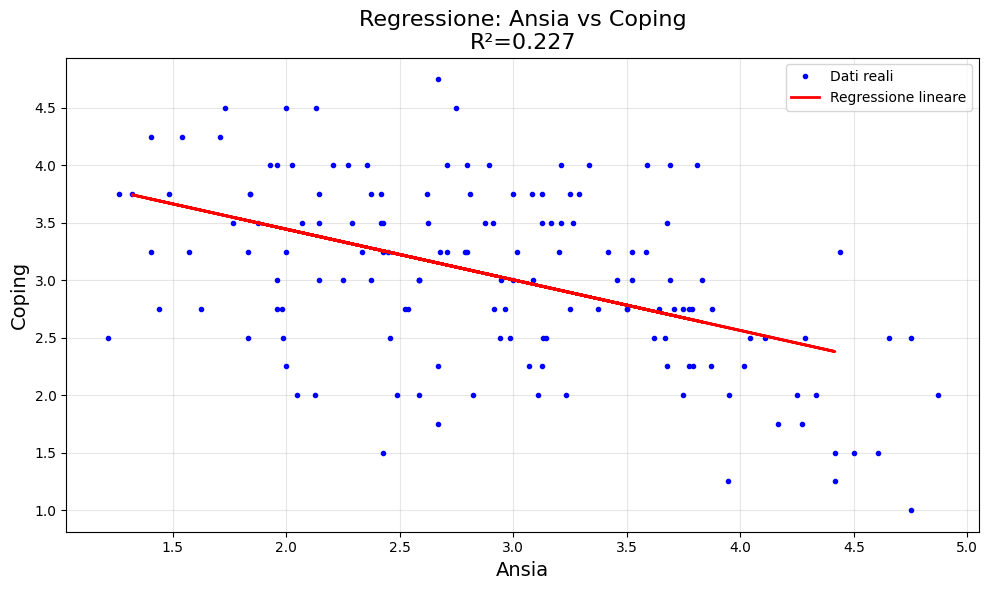

Coefficiente: -0.4405
Intercetta: 4.3253


In [43]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_3, y_3, "b.", label='Dati reali')
plt.plot(X_test_3[:,0], y_pred_3, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=14)
plt.ylabel("Coping", fontsize=14)
plt.title(f'Regressione: Ansia vs Coping\nR²={r2_3:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_lineare_ansia_coping")
plt.show()
 
print(f"Coefficiente: {lin_reg3.coef_[0]:.4f}")
print(f"Intercetta: {lin_reg3.intercept_:.4f}")

In [44]:
from sklearn.preprocessing import PolynomialFeatures

# trasformo X_test
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X_3.reshape(-1, 1))

In [45]:
model = LinearRegression()
model.fit(X_poly, y_3)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
y_pred_3_3 = model.predict(X_poly)
r2_3_3 = r2_score(y_3, y_pred_3_3)

In [47]:
mse_3_3 = mean_squared_error(y_3, y_pred_3_3)
r2_3_3 = r2_score(y_3, y_pred_3_3)
print("Mean Squared Error:", mse_3_3)
print("R-squared:", r2_3_3)

Mean Squared Error: 0.43972194955501603
R-squared: 0.2794455442531022


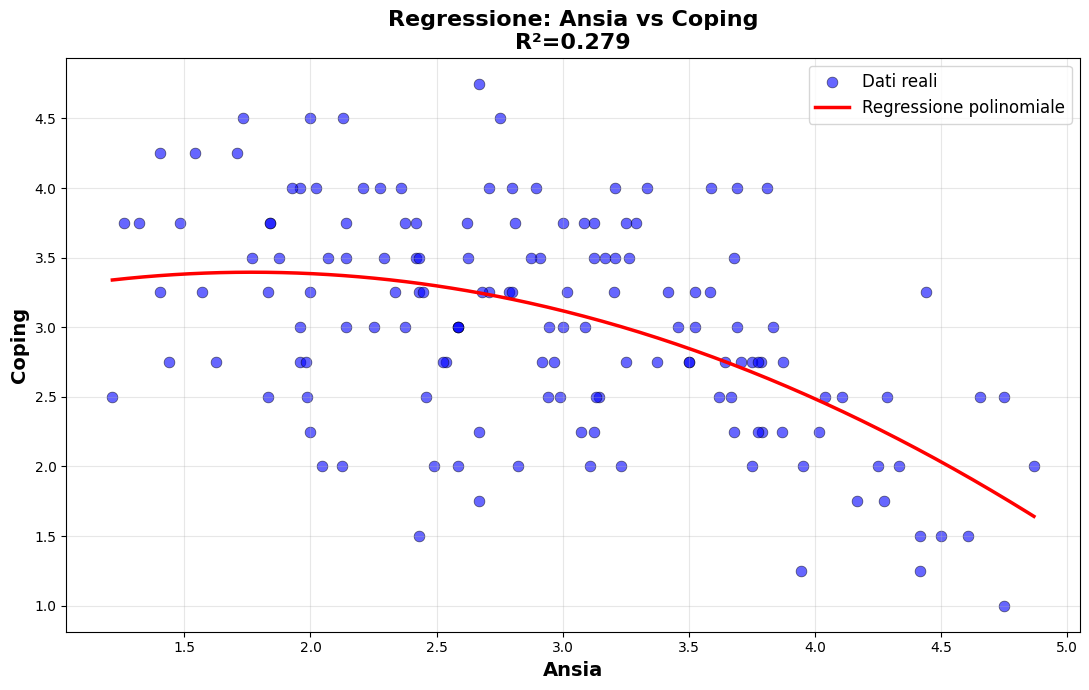

In [48]:
X_smooth = np.linspace(X_3.min(), X_3.max(), 300)
X_smooth_poly = poly_features.transform(X_smooth.reshape(-1, 1))
y_smooth = model.predict(X_smooth_poly)

# Grafico
fig, ax = plt.subplots(figsize=(11, 7))

# Scatter dei dati reali
ax.scatter(X_3, y_3, alpha=0.6, s=60, color='blue', 
          label='Dati reali', edgecolors='black', linewidth=0.5)

# Curva liscia di regressione
ax.plot(X_smooth, y_smooth, 'r-', linewidth=2.5, 
       label='Regressione polinomiale')

ax.set_xlabel("Ansia", fontsize=14, fontweight='bold')
ax.set_ylabel("Coping", fontsize=14, fontweight='bold')
ax.set_title(f'Regressione: Ansia vs Coping\nR²={r2_3_3:.3f}', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("regressione_poli2_ansia_evitamento")
plt.show()

In [49]:
poly_features = PolynomialFeatures(degree=3, include_bias=False)

# trasformo X_test
X_poly_3_2 = poly_features.fit_transform(X_3)

lin_reg3_3 = LinearRegression()

lin_reg3_3.fit(X_poly_3_2, y_3)

y_pred_3_3 = lin_reg3_3.predict(X_poly_3_2)

mse_3_3 = mean_squared_error(y_3, y_pred_3_3)
r2_3_3 = r2_score(y_3, y_pred_3_3)
print("Mean Squared Error:", mse_3_3)
print("R-squared:", r2_3_3)

Mean Squared Error: 0.43751166261793617
R-squared: 0.28306745146652146


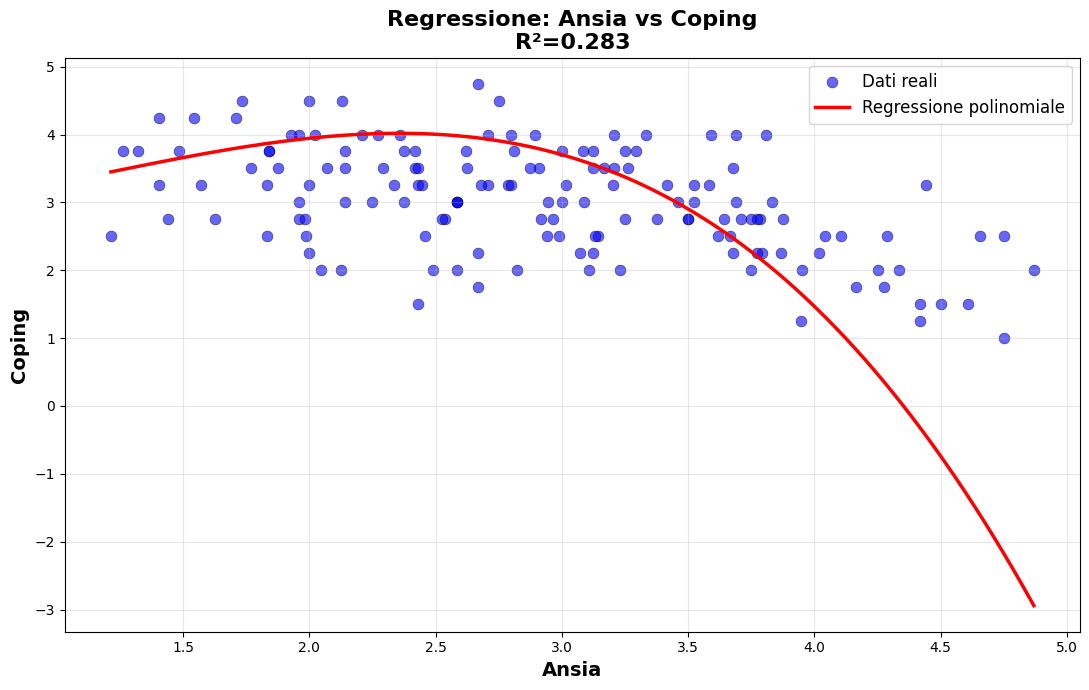

In [50]:
# X_smooth ordinato
X_smooth = np.linspace(X_3.min(), X_3.max(), 300)
X_smooth_poly = poly_features.transform(X_smooth.reshape(-1, 1))
y_smooth = model.predict(X_smooth_poly)

# Grafico
fig, ax = plt.subplots(figsize=(11, 7))

# Scatter dei dati reali
ax.scatter(X_3, y_3, alpha=0.6, s=60, color='blue', 
          label='Dati reali', edgecolors='black', linewidth=0.5)

# Curva liscia di regressione
ax.plot(X_smooth, y_smooth, 'r-', linewidth=2.5, 
       label='Regressione polinomiale')

ax.set_xlabel("Ansia", fontsize=14, fontweight='bold')
ax.set_ylabel("Coping", fontsize=14, fontweight='bold')
ax.set_title(f'Regressione: Ansia vs Coping\nR²={r2_3_3:.3f}', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("regressione_poli3_ansia_evitamento")
plt.show()

In [51]:
# cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Modello di regressione lineare
lin_reg_cv = LinearRegression()
scores_lin = cross_val_score(lin_reg_cv, X_3, y_3, cv=5, scoring='r2')
print(f"R² medio (lineare): {scores_lin.mean():.3f}")

# Modello di regressione polinomiale di grado 2
poly_reg_cv_2 = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
scores_poly_2 = cross_val_score(poly_reg_cv_2, X_3, y_3, cv=5, scoring='r2')
print(f"R² medio (polinomiale grado 2): {scores_poly_2.mean():.3f}")

R² medio (lineare): 0.215
R² medio (polinomiale grado 2): 0.245


### 4) Regressione: Ansia vs Gap

In [52]:
df_reg4 = df.copy()

df_reg4 = df_reg4.dropna(subset=['ansia', 'gap'])

In [53]:
X_4 = df_reg4['ansia'].values
y_4 = df_reg4['gap'].values

In [54]:
X_4= X_4.reshape(-1, 1)
y_4 = y_4.reshape(-1, 1)

In [55]:
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y_4, test_size=0.2, random_state=42)

In [56]:
# Modello
lin_reg4 = LinearRegression()
lin_reg4.fit(X_train_4, y_train_4)
y_pred_4 = lin_reg4.predict(X_test_4)

In [57]:
#valutazione
mse_4 = mean_squared_error(y_test_4, y_pred_4)
r2_4 = r2_score(y_test_4, y_pred_4)
print("Mean Squared Error:", mse_4)
print("R-squared:", r2_4)

Mean Squared Error: 1.0691536695357862
R-squared: 0.5357985358391348


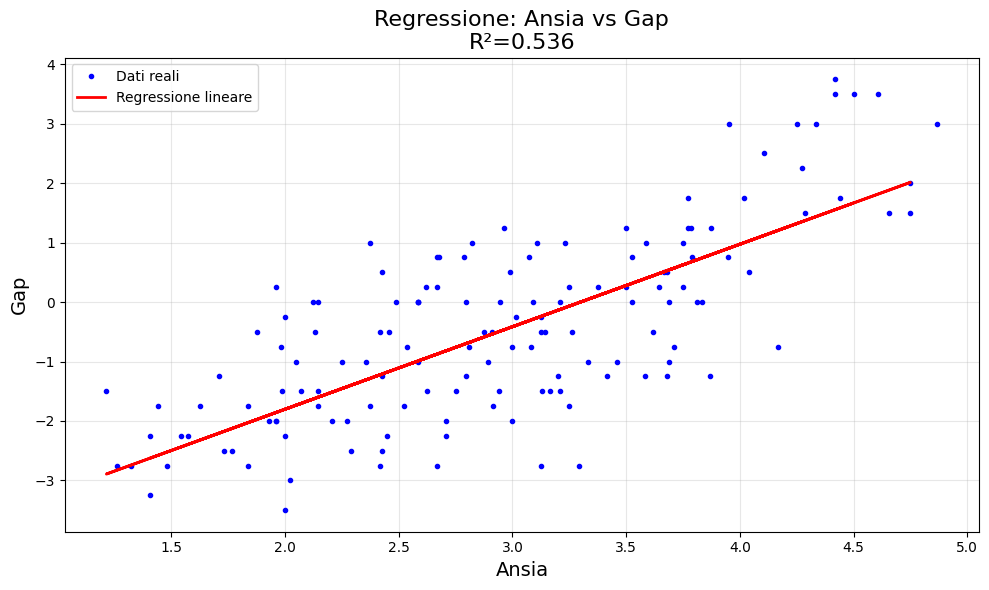

In [58]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_4, y_4, "b.", label='Dati reali')
plt.plot(X_test_4[:,0], y_pred_4, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=14)
plt.ylabel("Gap", fontsize=14)
plt.title(f'Regressione: Ansia vs Gap\nR²={r2_4:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_ansia_gap")
plt.show()

In [59]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)

# trasformo X_test
X_poly_4 = poly_features.fit_transform(X_4)

lin_reg4_2 = LinearRegression()

lin_reg4_2.fit(X_poly_4, y_4)

y_pred_4_2 = lin_reg4_2.predict(X_poly_4)

mse_4_2 = mean_squared_error(y_4, y_pred_4_2)
r2_4_2 = r2_score(y_4, y_pred_4_2)
print("Mean Squared Error:", mse_4_2)
print("R-squared:", r2_4_2)

Mean Squared Error: 1.086599703485499
R-squared: 0.5656596492296437


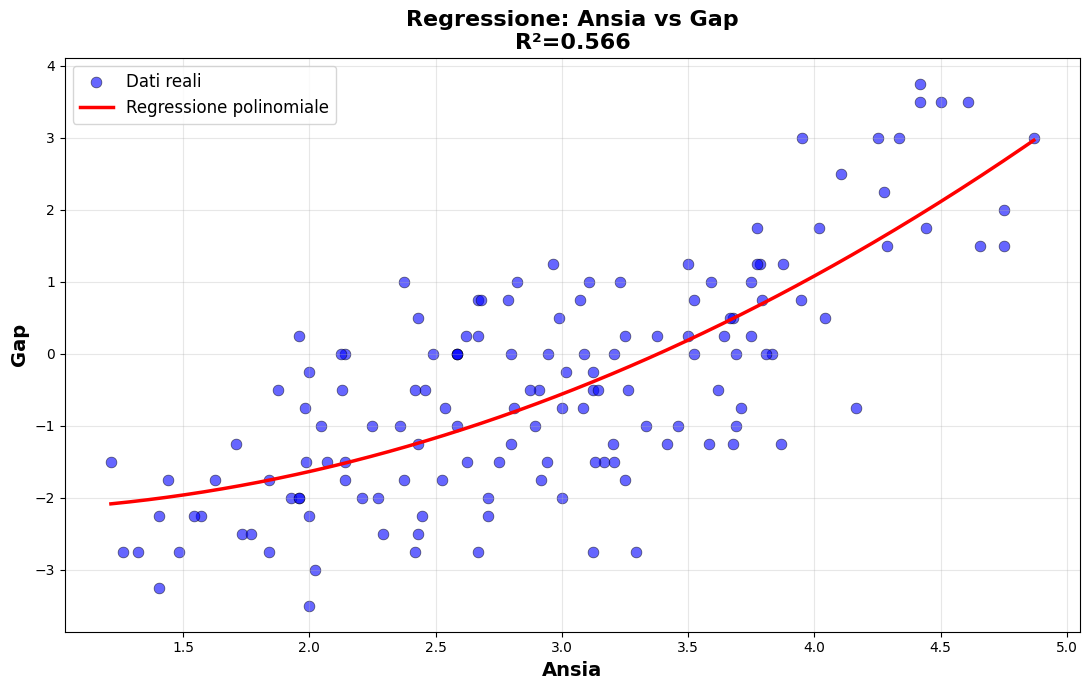

In [60]:
# X_smooth ordinato
X_smooth = np.linspace(X_4.min(), X_4.max(), 300)
X_smooth_poly = poly_features.transform(X_smooth.reshape(-1, 1))
y_smooth = lin_reg4_2.predict(X_smooth_poly)

# Grafico
fig, ax = plt.subplots(figsize=(11, 7))

# Scatter dei dati reali
ax.scatter(X_4, y_4, alpha=0.6, s=60, color='blue', 
          label='Dati reali', edgecolors='black', linewidth=0.5)

# Curva liscia di regressione
ax.plot(X_smooth, y_smooth, 'r-', linewidth=2.5, 
       label='Regressione polinomiale')

ax.set_xlabel("Ansia", fontsize=14, fontweight='bold')
ax.set_ylabel("Gap", fontsize=14, fontweight='bold')
ax.set_title(f'Regressione: Ansia vs Gap\nR²={r2_4_2:.3f}', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("regressione_poli4_ansia_gap")
plt.show()

In [61]:
poly_features = PolynomialFeatures(degree=3, include_bias=False)

# trasformo X_test
X_poly_4_2 = poly_features.fit_transform(X_4)

lin_reg4_3 = LinearRegression()

lin_reg4_3.fit(X_poly_4_2, y_4)

y_pred_4_3 = lin_reg4_3.predict(X_poly_4_2)

mse_4_3 = mean_squared_error(y_4, y_pred_4_3)
r2_4_3 = r2_score(y_4, y_pred_4_3)
print("Mean Squared Error:", mse_4_3)
print("R-squared:", r2_4_3)

Mean Squared Error: 1.0618642339790714
R-squared: 0.5755470184857081


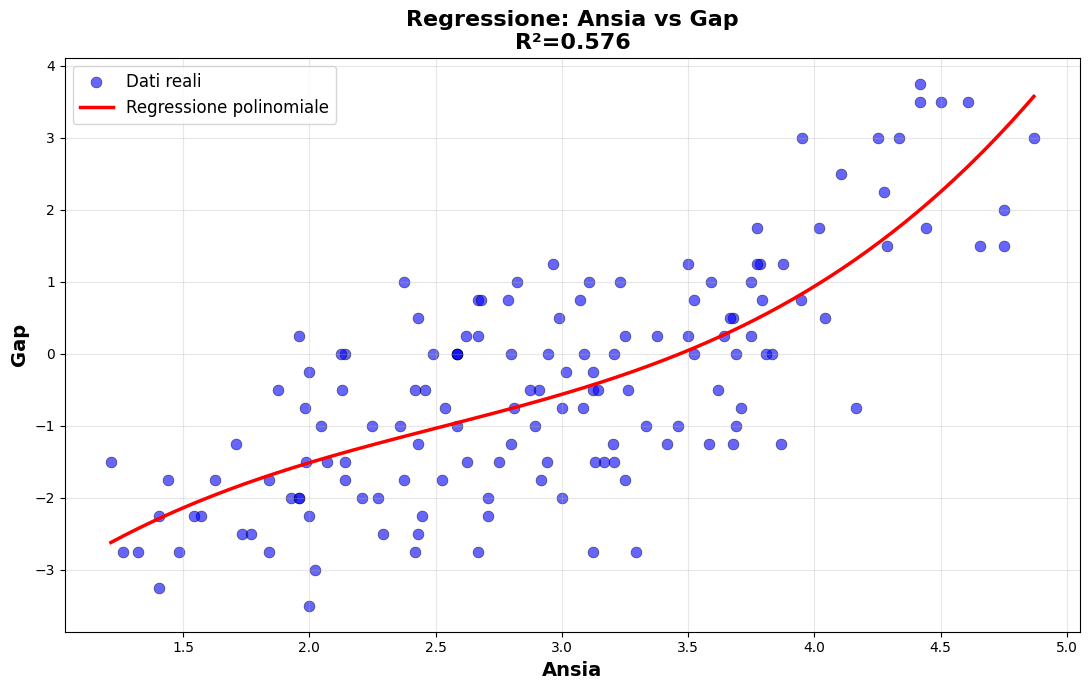

In [62]:
# X_smooth ordinato
X_smooth = np.linspace(X_4.min(), X_4.max(), 300)
X_smooth_poly = poly_features.transform(X_smooth.reshape(-1, 1))
y_smooth = lin_reg4_3.predict(X_smooth_poly)

# Grafico
fig, ax = plt.subplots(figsize=(11, 7))

# Scatter dei dati reali
ax.scatter(X_4, y_4, alpha=0.6, s=60, color='blue', 
          label='Dati reali', edgecolors='black', linewidth=0.5)

# Curva liscia di regressione
ax.plot(X_smooth, y_smooth, 'r-', linewidth=2.5, 
       label='Regressione polinomiale')

ax.set_xlabel("Ansia", fontsize=14, fontweight='bold')
ax.set_ylabel("Gap", fontsize=14, fontweight='bold')
ax.set_title(f'Regressione: Ansia vs Gap\nR²={r2_4_3:.3f}', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("regressione_poli5_ansia_gap")
plt.show()

In [63]:
# cross-validation

# Modello di regressione lineare
lin_reg_cv = LinearRegression()
scores_lin = cross_val_score(lin_reg_cv, X_4, y_4, cv=3, scoring='r2')
print(f"R² medio (lineare): {scores_lin.mean():.3f}")

# Modello di regressione polinomiale di grado 2
poly_reg_cv = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
scores_poly2 = cross_val_score(poly_reg_cv, X_4, y_4, cv=3, scoring='r2')
print(f"R² medio (polinomiale grado 2): {scores_poly2.mean():.3f}")

# Modello di regressione polinomiale di grado 3 
poly3_reg_cv = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression())
scores_poly3 = cross_val_score(poly3_reg_cv, X_4, y_4, cv=3, scoring='r2')
print(f"R² medio (polinomiale grado 3): {scores_poly3.mean():.3f}")

R² medio (lineare): 0.499
R² medio (polinomiale grado 2): 0.519
R² medio (polinomiale grado 3): 0.527


In [64]:
# split stratificato
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in kf.split(X_4):  # ← NO Y!
    X_train, X_test = X_4[train_idx], X_4[test_idx]
    y_train, y_test = y_4[train_idx], y_4[test_idx]

# Modello di regressione lineare
lin_reg_kf = LinearRegression()
lin_reg_kf.fit(X_train, y_train)
y_pred_kf = lin_reg_kf.predict(X_test)
mse_kf = mean_squared_error(y_test, y_pred_kf)
r2_kf = r2_score(y_test, y_pred_kf)
print(f"Fold MSE: {mse_kf:.3f}, R²: {r2_kf:.3f}")

# Modello di regressione polinomiale di grado 2
poly_reg_kf = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_reg_kf.fit(X_train, y_train)
y_pred_poly_kf = poly_reg_kf.predict(X_test)
mse_poly_kf = mean_squared_error(y_test, y_pred_poly_kf)
r2_poly_kf = r2_score(y_test, y_pred_poly_kf)
print(f"Fold MSE (polinomiale grado 2): {mse_poly_kf:.3f}, R²: {r2_poly_kf:.3f}")


Fold MSE: 1.247, R²: 0.279
Fold MSE (polinomiale grado 2): 1.124, R²: 0.350


In [65]:
# grid search
from sklearn.model_selection import GridSearchCV
param_grid = {
    'polynomialfeatures__degree': [1, 2, 3, 4, 5],
    'linearregression__fit_intercept': [True, False]
}
pipeline = make_pipeline(PolynomialFeatures(include_bias=False), LinearRegression())
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2')
grid_search.fit(X_4, y_4)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best R²: {grid_search.best_score_:.3f}")


Best parameters: {'linearregression__fit_intercept': True, 'polynomialfeatures__degree': 3}
Best R²: 0.527
